# Regresión lineal — grid de ventanas temporales

Evaluamos regresión lineal multivariante para todas las combinaciones de:
- **Ventana de entrada**: 5, 10, 30, 90 días
- **Ventana de salida**: 1, 5, 30, 90 días

Métrica: **MAE** (Mean Absolute Error) calculado sobre **train** y **test** (últimos 10% de la serie, sin shuffle). Comparar ambos sirve para detectar overfitting.

In [15]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

from util import get_train_test

## Configuración del grid

In [16]:
input_windows = [5, 10, 30, 90]
output_windows = [1, 5, 30, 90]

## Entrenamiento y evaluación

Para cada combinación:
1. Generamos X, y con `get_train_test` (los retornos se cargan una sola vez gracias al caché).
2. Aplanamos X de `(n, input_w, features)` a `(n, input_w * features)` para sklearn.
3. Ajustamos un `LinearRegression` multi-output y calculamos MAE sobre **train** y **test**.

In [17]:
results = []

for in_w in input_windows:
    for out_w in output_windows:
        d = get_train_test(input_window_size=in_w, output_window_size=out_w)

        X_tr = d.X_train.reshape(d.X_train.shape[0], -1)
        X_te = d.X_test.reshape(d.X_test.shape[0], -1)

        model = LinearRegression()
        model.fit(X_tr, d.y_train)

        y_pred_tr = model.predict(X_tr)
        y_pred_te = model.predict(X_te)

        mae_tr = mean_absolute_error(d.y_train, y_pred_tr)
        mae_te = mean_absolute_error(d.y_test, y_pred_te)

        results.append({
            "input_window": in_w,
            "output_window": out_w,
            "MAE_train": mae_tr,
            "MAE_test": mae_te,
        })
        print(f"input={in_w:>3}d, output={out_w:>3}d  ->  MAE train = {mae_tr:.6f} | MAE test = {mae_te:.6f}")

results_df = pd.DataFrame(results)
results_df

input=  5d, output=  1d  ->  MAE train = 0.011543 | MAE test = 0.012372
input=  5d, output=  5d  ->  MAE train = 0.005313 | MAE test = 0.005621
input=  5d, output= 30d  ->  MAE train = 0.002143 | MAE test = 0.002338
input=  5d, output= 90d  ->  MAE train = 0.001229 | MAE test = 0.001271
input= 10d, output=  1d  ->  MAE train = 0.011524 | MAE test = 0.012526
input= 10d, output=  5d  ->  MAE train = 0.005293 | MAE test = 0.005687
input= 10d, output= 30d  ->  MAE train = 0.002133 | MAE test = 0.002355
input= 10d, output= 90d  ->  MAE train = 0.001225 | MAE test = 0.001281
input= 30d, output=  1d  ->  MAE train = 0.011420 | MAE test = 0.012862
input= 30d, output=  5d  ->  MAE train = 0.005222 | MAE test = 0.005858
input= 30d, output= 30d  ->  MAE train = 0.002101 | MAE test = 0.002426
input= 30d, output= 90d  ->  MAE train = 0.001204 | MAE test = 0.001340
input= 90d, output=  1d  ->  MAE train = 0.011010 | MAE test = 0.013896
input= 90d, output=  5d  ->  MAE train = 0.005016 | MAE test = 0

,input_window,output_window,MAE_train,MAE_test
0,5,1,0.011543,0.012372
1,5,5,0.005313,0.005621
2,5,30,0.002143,0.002338
3,5,90,0.001229,0.001271
4,10,1,0.011524,0.012526
5,10,5,0.005293,0.005687
6,10,30,0.002133,0.002355
7,10,90,0.001225,0.001281
8,30,1,0.011420,0.012862
9,30,5,0.005222,0.005858


## Matrices de MAE (train y test)

In [18]:
mae_train_matrix = results_df.pivot(index="input_window", columns="output_window", values="MAE_train")
mae_test_matrix  = results_df.pivot(index="input_window", columns="output_window", values="MAE_test")

print("MAE — TRAIN")
display(mae_train_matrix)

print("MAE — TEST")
display(mae_test_matrix)

print("Gap (test - train) — cuanto mayor, más overfitting")
display(mae_test_matrix - mae_train_matrix)

MAE — TRAIN


output_window,1,5,30,90
input_window,,,,
5,0.011543,0.005313,0.002143,0.001229
10,0.011524,0.005293,0.002133,0.001225
30,0.011420,0.005222,0.002101,0.001204
90,0.011010,0.005016,0.001994,0.001137


MAE — TEST


output_window,1,5,30,90
input_window,,,,
5,0.012372,0.005621,0.002338,0.001271
10,0.012526,0.005687,0.002355,0.001281
30,0.012862,0.005858,0.002426,0.001340
90,0.013896,0.006266,0.002595,0.001477


Gap (test - train) — cuanto mayor, más overfitting


output_window,1,5,30,90
input_window,,,,
5,0.000829,0.000308,0.000195,0.000042
10,0.001002,0.000393,0.000222,0.000056
30,0.001442,0.000636,0.000325,0.000136
90,0.002886,0.001251,0.000601,0.000340


## Heatmap

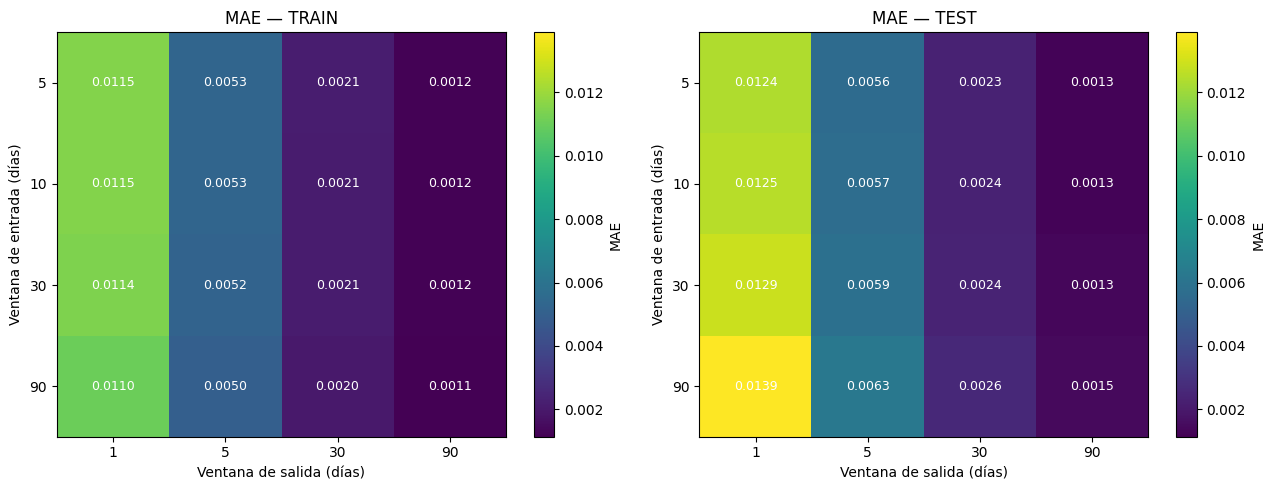

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Misma escala de color para que sean directamente comparables
vmin = min(mae_train_matrix.values.min(), mae_test_matrix.values.min())
vmax = max(mae_train_matrix.values.max(), mae_test_matrix.values.max())

for ax, matrix, title in [
    (axes[0], mae_train_matrix, "MAE — TRAIN"),
    (axes[1], mae_test_matrix, "MAE — TEST"),
]:
    im = ax.imshow(matrix.values, cmap="viridis", aspect="auto", vmin=vmin, vmax=vmax)
    ax.set_xticks(range(len(matrix.columns)))
    ax.set_xticklabels(matrix.columns)
    ax.set_yticks(range(len(matrix.index)))
    ax.set_yticklabels(matrix.index)
    ax.set_xlabel("Ventana de salida (días)")
    ax.set_ylabel("Ventana de entrada (días)")
    ax.set_title(title)
    for i in range(matrix.shape[0]):
        for j in range(matrix.shape[1]):
            ax.text(j, i, f"{matrix.values[i, j]:.4f}",
                    ha="center", va="center", color="white", fontsize=9)
    plt.colorbar(im, ax=ax, label="MAE")

plt.tight_layout()
plt.show()

## Mejor combinación

In [20]:
best = results_df.loc[results_df["MAE_test"].idxmin()]
print(f"Mejor combinación (por MAE test): input={int(best.input_window)}d, output={int(best.output_window)}d")
print(f"MAE train: {best.MAE_train:.6f}")
print(f"MAE test:  {best.MAE_test:.6f}")

Mejor combinación (por MAE test): input=5d, output=90d
MAE train: 0.001229
MAE test:  0.001271


## Guardar como benchmark

Guardamos los MAE del grid como benchmark de referencia. El resto de notebooks (MLP, RNN, etc.) se comparan contra este CSV usando `compare_to_benchmark()` y `plot_benchmark_comparison()` de `util.py`.

In [21]:
from util import save_benchmark

path = save_benchmark(results_df, "lr_benchmark")
print(f"Benchmark guardado en: {path}")

Benchmark guardado en: /Users/jchulvi/projects/Neural-Networks-Forecasting/data/lr_benchmark.csv
